In [24]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

In [76]:
path_test = "./test"
path_train = "./train"

In [98]:
test_metadata = pd.DataFrame()
train_metadata = pd.DataFrame()
test = pd.DataFrame()
train = pd.DataFrame()

In [99]:
for root, dirs, files in os.walk(path_test):
    for file in files:
        info = {}
        if file.endswith(".txt"):
            file = file[:-4]
            if file.startswith("steth"):
                metadata = file.split('_')
                info["dev"] = metadata[0]
                info["date"] = metadata[1]
                info["HH"] = metadata[2]
                info["MM"] = metadata[3]
                info["ss"] = metadata[4]
            else:
                metadata = file.split('_')
                info["dev"] = metadata[0]
                dates = metadata[1].split('-')
                info["date"] = dates[0]+dates[1]+dates[2]
                info["HH"] = dates[3]
                info["MM"] = dates[4]
                info["ss"] = dates[5]
            info["audio"] = file+".wav"
            new_row_df = pd.DataFrame([info])
            test_metadata = pd.concat([test_metadata, new_row_df])

for root, dirs, files in os.walk(path_train):
    for file in files:
        info = {}
        if file.endswith(".txt"):
            file = file[:-4]
            if file.startswith("steth"):
                metadata = file.split('_')
                info["dev"] = metadata[0]
                info["date"] = metadata[1]
                info["HH"] = metadata[2]
                info["MM"] = metadata[3]
                info["ss"] = metadata[4]
            else:
                metadata = file.split('_')
                info["dev"] = metadata[0]
                dates = metadata[1].split('-')
                info["date"] = dates[0]+dates[1]+dates[2]
                info["HH"] = dates[3]
                info["MM"] = dates[4]
                info["ss"] = dates[5]
            info["audio"] = file+".wav"
            new_row_df = pd.DataFrame([info])
            train_metadata = pd.concat([train_metadata, new_row_df])

In [100]:
for root, dirs, files in os.walk(path_test):
    for file in files:
        info = {}
        if file.endswith(".txt"):
            with open(path_test+"/"+file, 'r') as labels:
                for line in labels:
                    split_content = line.split(" ")
                    info["label"] = split_content[0]
                    info["start"] = split_content[1]
                    info["end"] = split_content[2][:-2]
                    info["file"] = file[:-10]+".wav"
                    new_row_df = pd.DataFrame([info])
                    test = pd.concat([test, new_row_df])

for root, dirs, files in os.walk(path_train):
    for file in files:
        info = {}
        if file.endswith(".txt"):
            with open(path_train+"/"+file, 'r') as labels:
                for line in labels:
                    split_content = line.split(" ")
                    info["label"] = split_content[0]
                    info["start"] = split_content[1]
                    info["end"] = split_content[2][:-2]
                    info["file"] = file[:-10]+".wav"
                    new_row_df = pd.DataFrame([info])
                    train = pd.concat([train, new_row_df])

In [113]:
from datetime import datetime, timedelta

time_string = "00:00:01.93"

# Parse the time string into a datetime object
# We use a dummy date (e.g., 1900, 1, 1) as strptime requires a full date
dt_object = datetime.strptime(time_string, "%H:%M:%S.%f")

# Create a timedelta object representing the duration
# We subtract the dummy date to get only the time component as a timedelta
time_delta = dt_object - datetime(1900, 1, 1)

# Get the total seconds from the timedelta object
total_seconds = time_delta.total_seconds()


In [114]:
total_seconds

1.93

In [ ]:
test["start"] = pd.to_timedelta(test['start']).dt.total_seconds()
test["end"] = pd.to_timedelta(test['end']).dt.total_seconds()

In [118]:
train["start"] = pd.to_timedelta(train['start']).dt.total_seconds()
train["end"] = pd.to_timedelta(train['end']).dt.total_seconds()

In [119]:
train

,label,start,end,file
0,I,1.500,2.45,steth_20180814_09_37_11.wav
0,D,1.500,2.45,steth_20180814_09_37_11.wav
0,E,2.608,3.63,steth_20180814_09_37_11.wav
0,D,2.608,3.63,steth_20180814_09_37_11.wav
0,I,5.227,6.35,steth_20180814_09_37_11.wav
...,...,...,...,...
0,D,0.309,1.25,trunc_2019-07-31-11-20-43-L8_8.wav
0,I,4.974,6.19,trunc_2019-07-31-11-20-43-L8_8.wav
0,D,4.974,6.19,trunc_2019-07-31-11-20-43-L8_8.wav
0,I,10.077,11.29,trunc_2019-07-31-11-20-43-L8_8.wav


In [103]:
train[["label","file"]].groupby(["file"]).value_counts()

file                                 label  
steth_20180814_09_37_11.wav          D          5
                                     I          4
                                     E          3
                                     Rhonchi    1
steth_20180814_09_37_33.wav          D          6
                                               ..
trunc_2019-07-31-11-20-43-L8_12.wav  D          3
trunc_2019-07-31-11-20-43-L8_6.wav   E          2
                                     I          2
trunc_2019-07-31-11-20-43-L8_8.wav   D          3
                                     I          2
Name: count, Length: 18629, dtype: int64

Labels

I -> Inhalation

E -> Exhalation

D -> DAS: discontinuous adventitious sound (Crackles)

C -> CAS: continuous adventitious sound (Stridor, Wheeze and Rhonchi) ->  asthma, COPD, or pneumonia

Stridor

Wheeze

Rhonchi

In [104]:
train["label"].value_counts()

label
I          27223
E          15601
D          13794
Wheeze      7027
Rhonchi     3780
Stridor      657
Name: count, dtype: int64

In [105]:
test["label"].value_counts()

label
I          6872
E          2748
D          1812
Wheeze     1430
Rhonchi     960
Stridor      29
Name: count, dtype: int64

# Data preparation

In [126]:
from scipy.signal import iirnotch, butter, sosfilt, tf2sos, sosfiltfilt, spectrogram
from scipy.io.wavfile import read
import librosa
from tqdm import tqdm
import torchaudio.transforms as T
import torch
from sklearn.manifold import TSNE

In [107]:
sr = 4000
data, samplerate = librosa.load('./test/steth_20190801_09_46_05.wav', sr=sr)

In [108]:
sos = butter(N=10, Wn=80*2*np.pi, btype='high', fs=sr, output="sos")
filtered = sosfilt(sos, data)

In [109]:
S = librosa.stft(filtered, n_fft=256, hop_length=int(256*(1-0.75)), win_length=256)
spect = np.abs(S)

# Obtener ejes de tiempo y frecuencia
f = librosa.fft_frequencies(sr=sr, n_fft=256)
t = librosa.frames_to_time(np.arange(spect.shape[1]), sr=sr, hop_length=int(256*(1-0.75)))
DB_orig = librosa.amplitude_to_db(spect, ref=np.max)

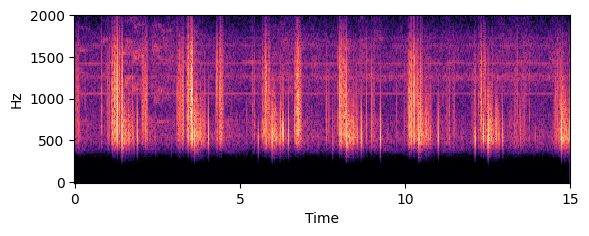

In [110]:
ax1 = plt.subplot(2, 1, 1)
librosa.display.specshow(
    DB_orig,
    sr=sr,
    hop_length=int(256*(1-0.75)),
    x_axis='time',
    y_axis='linear',
    ax=ax1
)

In [111]:
mel_spec = T.MelSpectrogram(sample_rate=sr, n_mels=256, n_fft=256, hop_length=int(256*(1-0.75)))
mfcc_transform = T.MFCC(sample_rate=sr, n_mfcc=64, melkwargs={"n_fft":256, "n_mels":128, "hop_length":int(256*(1-0.75))})

c:\Users\camsp\anaconda3\envs\cfcrl\Lib\site-packages\torchaudio\functional\functional.py:582: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (256) may be set too high. Or, the value for `n_freqs` (129) may be set too low.
  warnings.warn(
c:\Users\camsp\anaconda3\envs\cfcrl\Lib\site-packages\torchaudio\functional\functional.py:582: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (129) may be set too low.
  warnings.warn(


In [124]:
spect_list = []
labels = []
device_list = []
long_silence_list = []
sr = 4000

for i, row in tqdm(train.iterrows(), total=len(train)):
    path = f"{path_train}/{row['file']}"
    start_s, end_s = row['start'], row['end']
    label = f"{row['label']}"

    try:
        wav, fs = librosa.load(path)      # shape (1, N) o (2, N)

        # Extraer numpy del segmento
        start, end = int(start_s * sr), int(end_s * sr)
        segment = wav[start:end]      # numpy array

        sos = butter(N=10, Wn=80*2*np.pi, btype='high', fs=sr, output="sos")
        filtered = sosfilt(sos, data)

        segment_tensor = torch.tensor(segment.copy(), dtype=torch.float32).unsqueeze(0)

        mfcc = mfcc_transform(segment_tensor)            # (1, 64, T)
        mfcc_mean = mfcc.mean(dim=-1).squeeze(0).numpy()  # (64,)

        # S = librosa.stft(filtered, n_fft=800, hop_length=int(256*(1-0.75)), win_length=256)
        # spect = np.abs(S)

        # # Obtener ejes de tiempo y frecuencia
        # f = librosa.fft_frequencies(sr=sr, n_fft=800)
        # t = librosa.frames_to_time(np.arange(spect.shape[1]), sr=sr, hop_length=int(256*(1-0.75)))
        # DB_orig = librosa.amplitude_to_db(spect, ref=np.max)

        # Guardar resultados
        spect_list.append(mfcc_mean)
        labels.append(label)

    except Exception as e:
        print(f"Error en {row['file']} -> {e}")
        print(segment.shape)
        print(wav.shape)

        print(start)
        print(end)

        print(start_s)
        print(end_s)
        continue

  3%|▎         | 1905/68082 [00:10<06:26, 171.14it/s]

Error en steth_20181001_11_01_50.wav -> Argument #4: Padding size should be less than the corresponding input dimension, but got: padding (128, 128) at dimension 2 of input [1, 1, 92]
(92,)
(330750,)
59908
60000
14.977
15.0


 16%|█▌        | 10762/68082 [00:59<05:10, 184.36it/s]

Error en steth_20190124_08_14_26.wav -> Argument #4: Padding size should be less than the corresponding input dimension, but got: padding (128, 128) at dimension 2 of input [1, 1, 116]
(116,)
(330750,)
59884
60000
14.971
15.0


 23%|██▎       | 15340/68082 [01:24<04:55, 178.52it/s]

...

 41%|████      | 27666/68082 [02:33<03:27, 194.62it/s]

Error en steth_20190722_16_26_39.wav -> Argument #4: Padding size should be less than the corresponding input dimension, but got: padding (128, 128) at dimension 2 of input [1, 1, 92]
(92,)
(330750,)
59908
60000
14.977
15.0


 44%|████▍     | 29846/68082 [02:46<03:31, 180.70it/s]

Error en steth_20190728_13_45_52.wav -> Argument #4: Padding size should be less than the corresponding input dimension, but got: padding (128, 128) at dimension 2 of input [1, 1, 84]
(84,)
(330750,)
59916
60000
14.979
15.0
Error en steth_20190728_13_45_52.wav -> Argument #4: Padding size should be less than the corresponding input dimension, but got: padding (128, 128) at dimension 2 of input [1, 1, 84]
(84,)
(330750,)
59916
60000
14.979
15.0


100%|██████████| 68082/68082 [06:34<00:00, 172.74it/s]


In [127]:
X = np.stack(spect_list)
tsne = TSNE(n_components=2, perplexity=80, random_state=42)
X_embedded = tsne.fit_transform(X)

In [128]:
df_tsne = pd.DataFrame(X_embedded, columns=["tsne_1", "tsne_2"])
df_tsne["label"] = labels

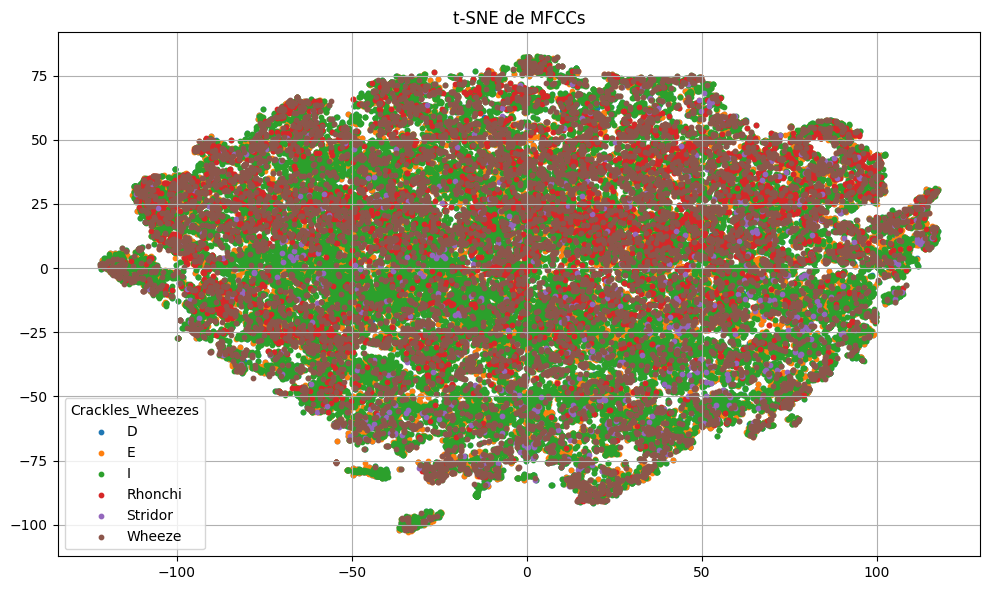

In [129]:
plt.figure(figsize=(10, 6))
for l in sorted(set(labels)):
    sub = df_tsne[df_tsne["label"] == l]
    plt.scatter(sub["tsne_1"], sub["tsne_2"], label=l, s=10)
plt.legend(title="Crackles_Wheezes")
plt.title("t-SNE de MFCCs")
plt.grid(True)
plt.tight_layout()
plt.show()